In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

DBSCAN Results (eps=0.7, min_samples=5):
  Number of clusters: 2
  Noise points: 0 (0.0%)
  Silhouette Score: 0.7434
  Adjusted Rand Index: 0.5681


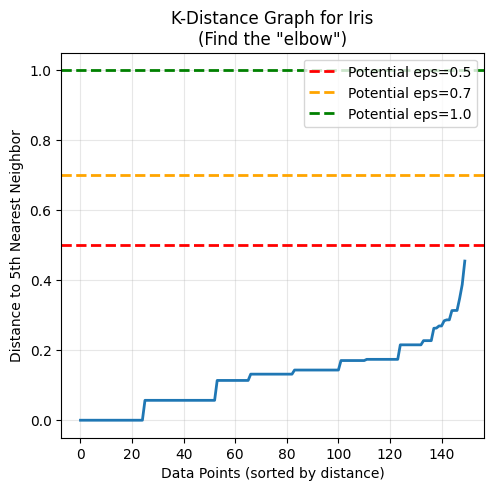

In [14]:
# data
iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# feature selection
X_petal = X[:, 2:4]  # petal_length, petal_width

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_petal)

# optimal eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, 4])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(distances_sorted, linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Potential eps=0.5')
plt.axhline(y=0.7, color='orange', linestyle='--', linewidth=2, label='Potential eps=0.7')
plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Potential eps=1.0')
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel('Distance to 5th Nearest Neighbor')
plt.title('K-Distance Graph for Iris\n(Find the "elbow")')
plt.legend()
plt.grid(True, alpha=0.3)

# model
best_eps = 0.7

dbscan = DBSCAN(eps=best_eps, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0) # remove noise from cluster labels
n_noise = np.sum(labels_dbscan == -1)
noise_ratio = n_noise / len(labels_dbscan)

print(f"DBSCAN Results (eps={best_eps}, min_samples=5):")
print(f"  Number of clusters: {n_clusters}")
print(f"  Noise points: {n_noise} ({noise_ratio*100:.1f}%)")

# score
if n_clusters > 1:
    mask = labels_dbscan != -1
    silhouette = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    ari = adjusted_rand_score(y_true[mask], labels_dbscan[mask])
    print(f"  Silhouette Score: {silhouette:.4f}")
    print(f"  Adjusted Rand Index: {ari:.4f}")

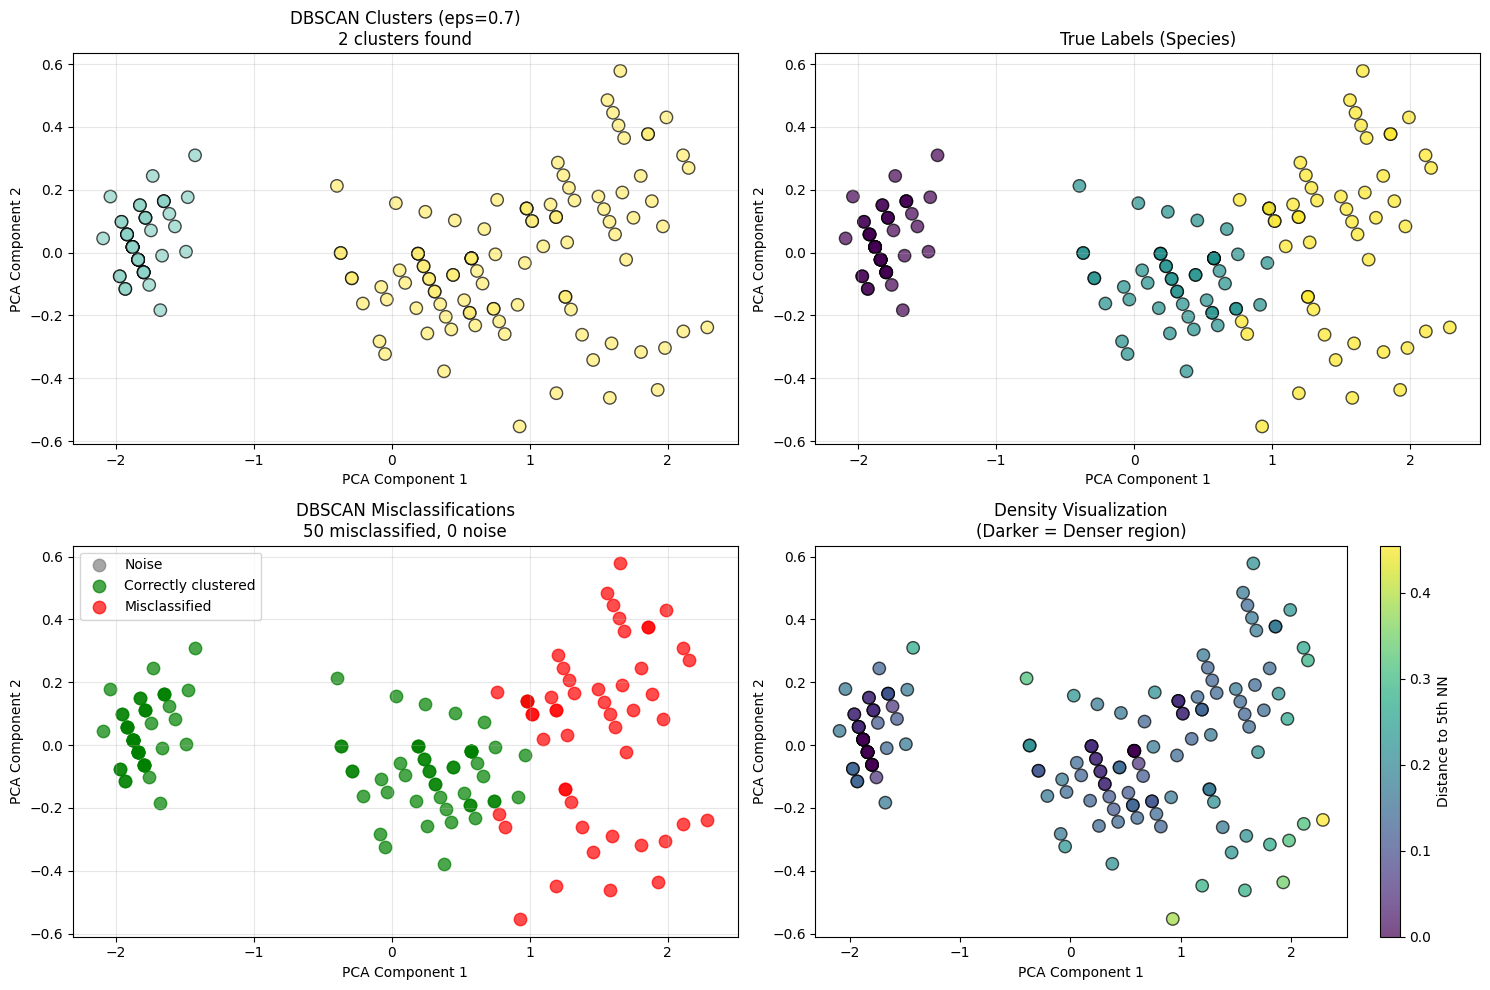

In [19]:
labels_dbscan_final = dbscan.labels_

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: DBSCAN Clusters
ax = axes[0, 0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan_final, cmap='Set3', s=80, alpha=0.7, edgecolors='black')
ax.set_title(f'DBSCAN Clusters (eps={best_eps})\n{len(set(labels_dbscan_final)) - (1 if -1 in labels_dbscan_final else 0)} clusters found')
ax.grid(True, alpha=0.3)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')

# Plot 2: True Labels
ax = axes[0, 1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=80, alpha=0.7, edgecolors='black')
ax.set_title('True Labels (Species)')
ax.grid(True, alpha=0.3)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')


# Plot 5: Misclassifications (DBSCAN vs True)
ax = axes[1, 0]
# DBSCAN may have noise points (-1), handle them
mask = labels_dbscan_final != -1
correct = (labels_dbscan_final[mask] == y_true[mask])
ax.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='gray', s=80, alpha=0.7, label='Noise')
ax.scatter(X_pca[mask][correct, 0], X_pca[mask][correct, 1], 
           c='green', s=80, alpha=0.7, label='Correctly clustered')
ax.scatter(X_pca[mask][~correct, 0], X_pca[mask][~correct, 1], 
           c='red', s=80, alpha=0.7, label='Misclassified')
ax.set_title(f'DBSCAN Misclassifications\n{(~correct).sum()} misclassified, {n_noise} noise')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')

# Plot 6: Distance to 5th nearest neighbor (density visualization)
ax = axes[1, 1]
dist_5nn = distances[:, 4]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=dist_5nn, cmap='viridis', s=80, alpha=0.7, edgecolors='black')
ax.set_title('Density Visualization\n(Darker = Denser region)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
plt.colorbar(scatter, ax=ax, label='Distance to 5th NN')

plt.tight_layout()
plt.show()


eps      Clusters   Noise      Silhouette   ARI        Visual Quality
----------------------------------------------------------------------
0.3      2          2          0.7480       0.5732     ⚠️ Under-segmented
0.5      2          0          0.7434       0.5681     ⚠️ Under-segmented
0.7      2          0          0.7434       0.5681     ⚠️ Under-segmented
1.0      2          0          0.7434       0.5681     ⚠️ Under-segmented
1.2      1          0          nan          nan        ❌ Under-segmented
1.5      1          0          nan          nan        ❌ Under-segmented


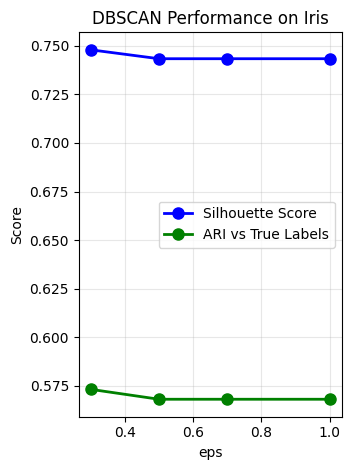

In [7]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]
results = []

print(f"{'eps':<8} {'Clusters':<10} {'Noise':<10} {'Silhouette':<12} {'ARI':<10} {'Visual Quality'}")
print("-"*70)

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)
    
    if n_clusters > 1:
        mask = labels != -1
        silhouette = silhouette_score(X_scaled[mask], labels[mask])
        ari = adjusted_rand_score(y_true[mask], labels[mask])
    else:
        silhouette = np.nan
        ari = np.nan
    
    # Visual quality assessment
    if n_clusters == 3 and noise_ratio < 0.05:
        visual = "⭐ Perfect"
    elif n_clusters == 3 and noise_ratio < 0.15:
        visual = "✅ Good"
    elif n_clusters == 2 and noise_ratio < 0.1:
        visual = "⚠️ Under-segmented"
    elif n_clusters > 3:
        visual = "❌ Over-segmented"
    elif n_clusters == 1:
        visual = "❌ Under-segmented"
    else:
        visual = "❌ Poor"
    
    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette': silhouette,
        'ari': ari,
        'visual': visual
    })
    
    print(f"{eps:<8.1f} {n_clusters:<10} {n_noise:<10} {silhouette:<12.4f} {ari:<10.4f} {visual}")

plt.subplot(1, 2, 2)
eps_list = [r['eps'] for r in results]
silhouette_list = [r['silhouette'] for r in results]
ari_list = [r['ari'] for r in results]

plt.plot(eps_list, silhouette_list, 'bo-', linewidth=2, markersize=8, label='Silhouette Score')
plt.plot(eps_list, ari_list, 'go-', linewidth=2, markersize=8, label='ARI vs True Labels')
plt.xlabel('eps')
plt.ylabel('Score')
plt.title('DBSCAN Performance on Iris')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()